# 04 — Hybrid lift: actuals while we have them, CSV-derived projection after

Prototype of a different framing: instead of deriving the entire lift series from the CSV (and accepting a 110k undershoot in validation), use the **empirical Fenix gap as the lift directly** while we have actuals (2026-04-06 → 2026-05-19, the June forecast's training_end), then transition to the CSV's growth pattern for the future (post-2026-05-19).

**Recipe:**

```
For d < CAMPAIGN_LAUNCH (2026-04-06):       lift(d) = 0      (no campaign yet)
For CAMPAIGN_LAUNCH ≤ d ≤ training_end:     lift(d) = fenix_gap_daily(d)
For d > training_end (2026-05-19):          lift(d) = fenix_gap_daily(training_end)
                                                      + (csv_daily_paid(d) − csv_daily_paid(training_end))
```

- **Historical fit is exact by construction** (Validation A residual = 0 on the historical window).
- **Future is anchored to the empirical level at training_end**, then carries the CSV's growth pattern from there forward. No interpolation slope-calculation gymnastics.
- **No anchor choice required** — the anchor effectively becomes training_end, which is empirically given, not a modeling decision.

Output is exploratory. If the diagnostics look good, this becomes the new `02`-style model and we re-promote.


In [1]:
# [setup]
import hashlib
import json
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths
WEEKLY_PARQUET = Path('data/weekly_paid_dau_clean.parquet')
SOURCE_CSV = Path('data/paid_dau_weekly_forecast.20260519.csv')
OUT_PARQUET = Path('data/marketing_lift_model.hybrid.2026-05-19.parquet')
OUT_META = Path('data/marketing_lift_model.hybrid.2026-05-19.meta.json')
EXISTING_CONVOLUTION_PARQUET = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/marketing/'
    'marketing_lift_model.2026-05-16.parquet'
)
CURRENT_REAL_DATA_PARQUET = Path('data/marketing_lift_model.real_data.2026-05-19.parquet')

APRIL_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/'
    'mobile_cps0.02_thresh32_recent13_clip0.6/'
    'mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
)
JUNE_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/'
    'mobile_cps0.02_thresh32_recent13_clip0.6_cap426/'
    'mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'
)

# Dates
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')
PARQUET_START = pd.Timestamp('2026-02-01')
PARQUET_END = pd.Timestamp('2026-12-31')
BASELINE_START = pd.Timestamp('2026-02-01')
BASELINE_END = pd.Timestamp('2026-03-28')
LAST_HISTORICAL_DATE = pd.Timestamp('2026-05-19')  # CSV generation date / June training end

MA_WINDOW = 28

EASTER_MASK_DATES = pd.DatetimeIndex(sorted(set(
    [pd.Timestamp('2026-04-05') + pd.Timedelta(days=d) for d in range(-2, 3)] +
    [pd.Timestamp('2026-04-18') + pd.Timedelta(days=d) for d in range(-2, 3)]
)))


def _load_forecast(path):
    df = pd.read_parquet(path)
    df['target_date'] = pd.to_datetime(df['target_date'])
    return df


def _aggregate(df, country, app_name, data_type_filter=None):
    rollup = df[(df['data_source'] == 'glean_mobile')
                & (df['country'] == country)
                & (df['app_name'] == app_name)
                & (df['segment'] == '{}')].copy()
    if data_type_filter is not None:
        rollup = rollup[rollup['data_type'] == data_type_filter]
    return rollup.set_index('target_date').sort_index()['dau']


In [2]:
# [load-csv-daily]
# Same interpolation as nb2 — snapshot interpretation, linear interp between Mondays.
weekly = pd.read_parquet(WEEKLY_PARQUET).sort_values('week_starting').reset_index(drop=True)
weekly_indexed = weekly.set_index('week_starting')['total_paid_dau'].astype('float64')
daily_index = pd.date_range(weekly_indexed.index.min(), PARQUET_END, freq='D')
csv_daily_paid = weekly_indexed.reindex(daily_index).interpolate(method='linear', limit_area='inside').ffill()
assert csv_daily_paid.isna().sum() == 0

print(f'CSV-derived daily paid DAU: {csv_daily_paid.index.min().date()} → {csv_daily_paid.index.max().date()}')
print(f'  Days: {len(csv_daily_paid)}')
print(f'  Value at LAST_HISTORICAL_DATE ({LAST_HISTORICAL_DATE.date()}): {csv_daily_paid.loc[LAST_HISTORICAL_DATE]:>10,.0f}')
print(f'  Value at year-end: {csv_daily_paid.loc[PARQUET_END]:>10,.0f}')


CSV-derived daily paid DAU: 2026-01-05 → 2026-12-31
  Days: 361
  Value at LAST_HISTORICAL_DATE (2026-05-19):  1,147,768
  Value at year-end:  1,473,843


In [3]:
# [load-empirical-gap]
# Build the empirical Fenix Android gap = (June actuals − April mktg-off forecast)
# at the country='ALL', app_name='fenix_android' rollup.

april = _load_forecast(APRIL_FORECAST_PATH)
june = _load_forecast(JUNE_FORECAST_PATH)

april_fenix_all = _aggregate(april, country='ALL', app_name='fenix_android')
actuals_fenix_all = _aggregate(june, country='ALL', app_name='fenix_android', data_type_filter='training')

gap_overlap = april_fenix_all.index.intersection(actuals_fenix_all.index)
fenix_gap_daily = (actuals_fenix_all.reindex(gap_overlap)
                   - april_fenix_all.reindex(gap_overlap)).rename('fenix_gap_daily')

training_end_actual = actuals_fenix_all.dropna().index.max()
print(f'June Fenix actuals training_end: {training_end_actual.date()}')
print(f'Gap coverage: {fenix_gap_daily.index.min().date()} → {fenix_gap_daily.index.max().date()}')
print(f'Gap on CAMPAIGN_LAUNCH ({CAMPAIGN_LAUNCH.date()}):   {fenix_gap_daily.loc[CAMPAIGN_LAUNCH]:>+10,.0f}')
print(f'Gap on training_end_actual ({training_end_actual.date()}): {fenix_gap_daily.loc[training_end_actual]:>+10,.0f}')
print()
print('Daily gap stats (post-CAMPAIGN_LAUNCH):')
post = fenix_gap_daily.loc[CAMPAIGN_LAUNCH:training_end_actual]
print(f'  N days:   {len(post)}')
print(f'  Mean:     {post.mean():>+10,.0f}')
print(f'  Std:      {post.std():>+10,.0f}')
print(f'  Min:      {post.min():>+10,.0f}  at {post.idxmin().date()}')
print(f'  Max:      {post.max():>+10,.0f}  at {post.idxmax().date()}')


June Fenix actuals training_end: 2026-05-16
Gap coverage: 2021-01-01 → 2026-05-16
Gap on CAMPAIGN_LAUNCH (2026-04-06):       -3,985
Gap on training_end_actual (2026-05-16):   +494,378

Daily gap stats (post-CAMPAIGN_LAUNCH):
  N days:   41
  Mean:       +332,450
  Std:        +130,327
  Min:          -3,985  at 2026-04-06
  Max:        +591,504  at 2026-05-14


In [4]:
# [build-hybrid]
# Construct the hybrid daily lift series:
#   - Pre-campaign:               lift = 0
#   - Historical (post-campaign): lift = fenix_gap_daily (raw daily, no smoothing)
#   - Future:                     lift = gap_at_training_end + (csv_daily_paid(d) − csv_daily_paid(training_end))

training_end = training_end_actual

# Anchor for future portion
gap_at_training_end = float(fenix_gap_daily.loc[training_end])
csv_at_training_end = float(csv_daily_paid.loc[training_end])

print(f'Stitch parameters:')
print(f'  training_end:             {training_end.date()}')
print(f'  gap_at_training_end:      {gap_at_training_end:>+10,.0f}')
print(f'  csv_paid_at_training_end: {csv_at_training_end:>10,.0f}')
print()

# Build over the full PARQUET_START → PARQUET_END index
full_index = pd.date_range(PARQUET_START, PARQUET_END, freq='D')

# Future portion: anchored CSV growth
future_csv_delta = csv_daily_paid - csv_at_training_end
future_lift = future_csv_delta + gap_at_training_end

# Combine: historical = gap_daily, future = anchored CSV
hybrid_lift = pd.Series(0.0, index=full_index, name='marketing_lift_daily')

# Historical window: campaign launch → training_end
hist_mask = (full_index >= CAMPAIGN_LAUNCH) & (full_index <= training_end)
hist_dates = full_index[hist_mask]
hybrid_lift.loc[hist_dates] = fenix_gap_daily.reindex(hist_dates).values

# Future window: training_end + 1 → PARQUET_END
future_mask = full_index > training_end
future_dates = full_index[future_mask]
hybrid_lift.loc[future_dates] = future_lift.reindex(future_dates).values

# Sanity assertions
assert hybrid_lift.isna().sum() == 0, 'no NaN allowed'
assert (hybrid_lift.loc[:CAMPAIGN_LAUNCH - pd.Timedelta(days=1)] == 0.0).all(), 'pre-launch must be 0'
assert hybrid_lift.loc[training_end] == gap_at_training_end, 'continuity at training_end'
# Continuity check: gap_daily at training_end equals first future value at training_end + 1 day shifted by 1d of CSV growth
expected_next = gap_at_training_end + (csv_daily_paid.loc[training_end + pd.Timedelta(days=1)] - csv_at_training_end)
assert abs(hybrid_lift.loc[training_end + pd.Timedelta(days=1)] - expected_next) < 1e-6, 'first future day correct'

print('Hybrid lift snapshot:')
print(f'  {"date":>10}  {"lift_daily":>14}')
snapshot_dates = [pd.Timestamp('2026-03-01'),
                  CAMPAIGN_LAUNCH,
                  pd.Timestamp('2026-05-01'),
                  training_end,
                  training_end + pd.Timedelta(days=1),  # first future
                  pd.Timestamp('2026-07-01'),
                  pd.Timestamp('2026-09-01'),
                  pd.Timestamp('2026-12-15'),
                  PARQUET_END]
for d in snapshot_dates:
    label = ''
    if d < CAMPAIGN_LAUNCH:
        label = '(pre-launch, lift=0)'
    elif d <= training_end:
        label = '(historical, gap)'
    else:
        label = '(future, csv-anchored)'
    val = hybrid_lift.loc[d]
    print(f'  {d.date()}  {val:>+14,.0f}  {label}')


Stitch parameters:
  training_end:             2026-05-16
  gap_at_training_end:        +494,378
  csv_paid_at_training_end:  1,170,868

Hybrid lift snapshot:
        date      lift_daily
  2026-03-01              +0  (pre-launch, lift=0)
  2026-04-06          -3,985  (historical, gap)
  2026-05-01        +111,485  (historical, gap)
  2026-05-16        +494,378  (historical, gap)
  2026-05-17        +472,328  (future, csv-anchored)
  2026-07-01        +707,219  (future, csv-anchored)
  2026-09-01        +702,641  (future, csv-anchored)
  2026-12-15        +786,342  (future, csv-anchored)
  2026-12-31        +797,352  (future, csv-anchored)


In [5]:
# [compute-ma]
hybrid_lift_ma = (hybrid_lift
                  .rolling(window=MA_WINDOW, min_periods=14)
                  .mean()
                  .rename('marketing_lift_ma'))

# Also compute MAs for the empirical gap and the current real-data model — for plotting
fenix_gap_ma = fenix_gap_daily.rolling(MA_WINDOW, min_periods=14).mean().rename('fenix_gap_ma')

print('MA28 snapshot:')
print(f'  {"date":>10}  {"daily":>14}  {"ma28":>14}')
for d in [CAMPAIGN_LAUNCH, pd.Timestamp('2026-05-01'), training_end,
          pd.Timestamp('2026-07-01'), pd.Timestamp('2026-09-01'),
          pd.Timestamp('2026-12-15'), PARQUET_END]:
    daily_val = hybrid_lift.loc[d]
    ma_val = hybrid_lift_ma.loc[d]
    ma_str = f'{ma_val:>+14,.0f}' if pd.notna(ma_val) else f'{"NaN":>14}'
    print(f'  {d.date()}  {daily_val:>+14,.0f}  {ma_str}')


MA28 snapshot:
        date           daily            ma28
  2026-04-06          -3,985            -142
  2026-05-01        +111,485        +239,521
  2026-05-16        +494,378        +384,259
  2026-07-01        +707,219        +733,203
  2026-09-01        +702,641        +695,447
  2026-12-15        +786,342        +774,888
  2026-12-31        +797,352        +788,275


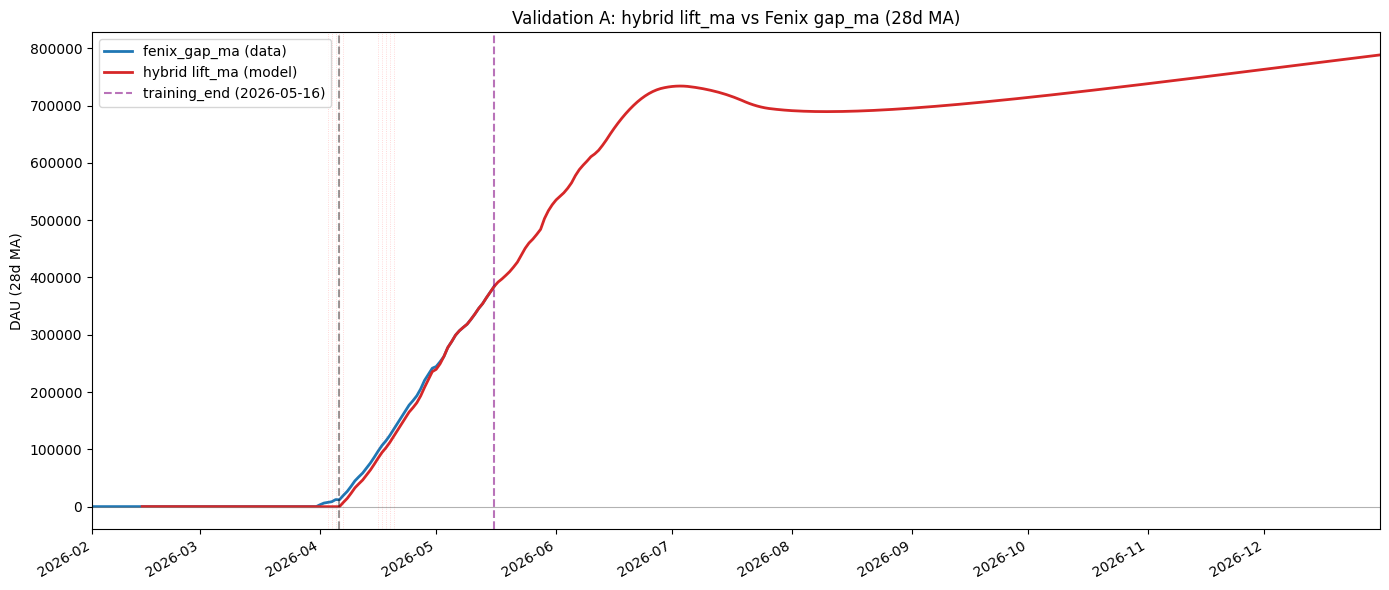

Validation A — residual (hybrid_lift_ma − fenix_gap_ma), post-campaign non-Easter days:
  N days:   34
  Mean:         -6,427
  Std:          +5,843
  RMSE:         +8,629  (expect small but not exactly zero — MA mixes future CSV-anchored values at the boundary)


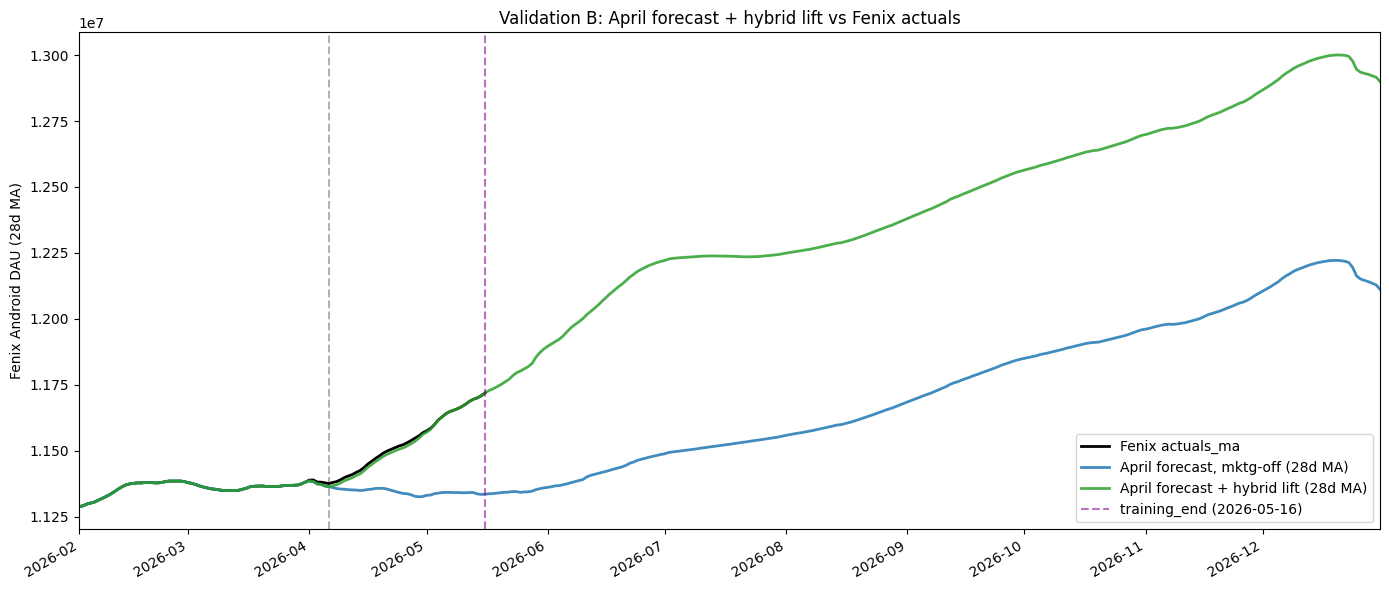

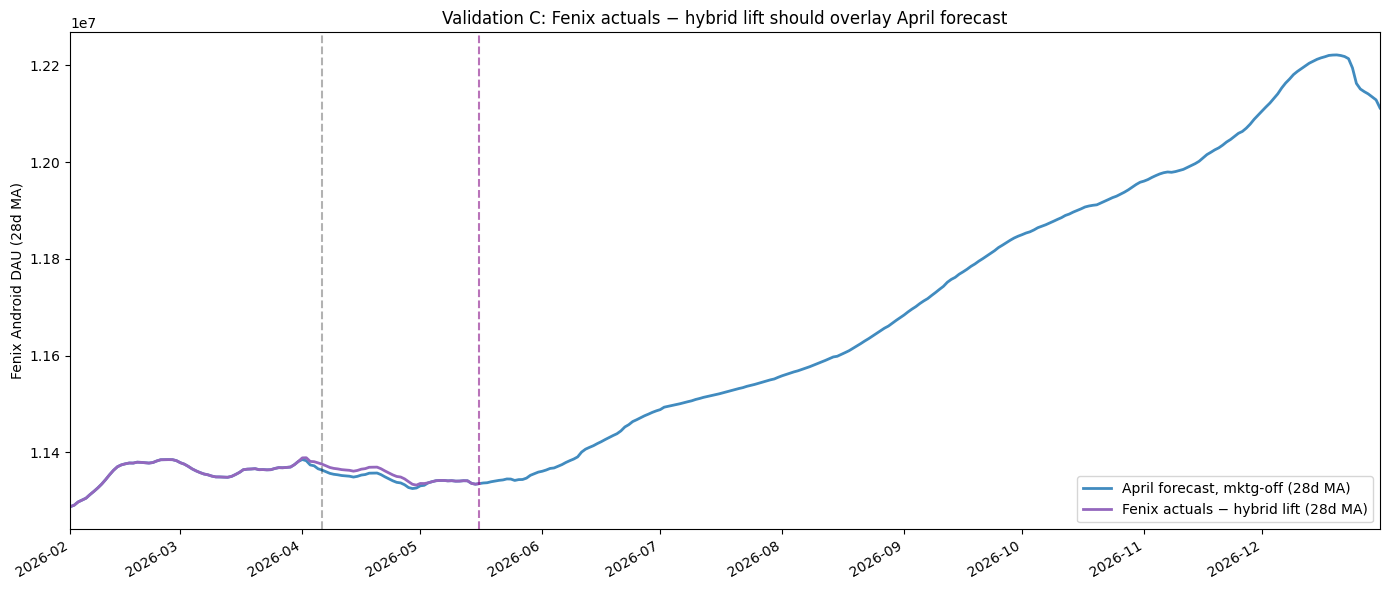

Validation C — counterfactual residual: (actuals − hybrid lift) − April forecast
  N days:   105
  Mean:         +3,252
  Std:          +5,176
  Min:              -0  at 2026-05-03
  Max:         +12,197  at 2026-04-05


In [6]:
# [validation]
# Three views:
#   A — does hybrid_lift_ma match fenix_gap_ma post-campaign? Historical: exact by construction. Future: by design tracks gap+CSV-delta.
#   B — does april_ma + hybrid_lift_ma overlay actuals_ma?
#   C — does (actuals_ma − hybrid_lift_ma) overlay april_ma?

actuals_ma = actuals_fenix_all.rolling(MA_WINDOW, min_periods=14).mean().rename('actuals_ma')
april_ma = april_fenix_all.rolling(MA_WINDOW, min_periods=14).mean().rename('april_ma')

PLOT_START = pd.Timestamp('2026-02-01')
PLOT_END = pd.Timestamp('2026-12-31')
plot_index = pd.date_range(PLOT_START, PLOT_END, freq='D')

actuals_ma_v = actuals_ma.reindex(plot_index)
april_ma_v = april_ma.reindex(plot_index)
gap_ma_v = fenix_gap_ma.reindex(plot_index)
hybrid_ma_v = hybrid_lift_ma.reindex(plot_index)
combined_ma_v = april_ma_v + hybrid_ma_v.fillna(0.0)
actuals_minus_hybrid_v = actuals_ma_v - hybrid_ma_v.fillna(0.0)

# --- Validation A ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(gap_ma_v.index, gap_ma_v, '-', linewidth=2, color='C0',
        label='fenix_gap_ma (data)')
ax.plot(hybrid_ma_v.index, hybrid_ma_v, '-', linewidth=2, color='C3',
        label='hybrid lift_ma (model)')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax.axvline(training_end, color='purple', linestyle='--', alpha=0.55,
           label=f'training_end ({training_end.date()})')
ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
for d in EASTER_MASK_DATES:
    ax.axvline(d, color='red', linestyle=':', linewidth=0.6, alpha=0.2)
ax.set_title('Validation A: hybrid lift_ma vs Fenix gap_ma (28d MA)')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlim(PLOT_START, PLOT_END)
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Residual stats on historical post-campaign non-Easter window
post_ix = pd.date_range(CAMPAIGN_LAUNCH, training_end, freq='D').difference(EASTER_MASK_DATES)
post_ix = post_ix.intersection(plot_index)
valid = hybrid_ma_v.reindex(post_ix).notna() & gap_ma_v.reindex(post_ix).notna()
post_ix = post_ix[valid]
a_resid = (hybrid_ma_v.reindex(post_ix) - gap_ma_v.reindex(post_ix))
a_resid_mean = float(a_resid.mean())
a_resid_std = float(a_resid.std())
a_resid_rmse = float(np.sqrt((a_resid ** 2).mean()))
print(f'Validation A — residual (hybrid_lift_ma − fenix_gap_ma), post-campaign non-Easter days:')
print(f'  N days:   {len(a_resid)}')
print(f'  Mean:     {a_resid_mean:>+10,.0f}')
print(f'  Std:      {a_resid_std:>+10,.0f}')
print(f'  RMSE:     {a_resid_rmse:>+10,.0f}  (expect small but not exactly zero — MA mixes future CSV-anchored values at the boundary)')

# --- Validation B ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(actuals_ma_v.index, actuals_ma_v, '-', linewidth=2, color='black',
        label='Fenix actuals_ma')
ax.plot(april_ma_v.index, april_ma_v, '-', linewidth=2, color='C0', alpha=0.85,
        label='April forecast, mktg-off (28d MA)')
ax.plot(combined_ma_v.index, combined_ma_v, '-', linewidth=2, color='C2', alpha=0.85,
        label='April forecast + hybrid lift (28d MA)')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.3)
ax.axvline(training_end, color='purple', linestyle='--', alpha=0.55,
           label=f'training_end ({training_end.date()})')
ax.set_xlim(PLOT_START, PLOT_END)
ax.set_title('Validation B: April forecast + hybrid lift vs Fenix actuals')
ax.set_ylabel('Fenix Android DAU (28d MA)')
ax.legend(fontsize=10, loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# --- Validation C ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(april_ma_v.index, april_ma_v, '-', linewidth=2, color='C0', alpha=0.85,
        label='April forecast, mktg-off (28d MA)')
have_actuals = actuals_ma_v.notna()
ax.plot(actuals_minus_hybrid_v.index[have_actuals],
        actuals_minus_hybrid_v[have_actuals],
        '-', linewidth=2, color='C4',
        label='Fenix actuals − hybrid lift (28d MA)')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.3)
ax.axvline(training_end, color='purple', linestyle='--', alpha=0.55)
ax.set_xlim(PLOT_START, PLOT_END)
ax.set_title('Validation C: Fenix actuals − hybrid lift should overlay April forecast')
ax.set_ylabel('Fenix Android DAU (28d MA)')
ax.legend(fontsize=10, loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

c_resid = (actuals_minus_hybrid_v - april_ma_v).dropna()
c_resid_mean = float(c_resid.mean())
c_resid_std = float(c_resid.std())
c_resid_min = float(c_resid.min())
c_resid_max = float(c_resid.max())
print(f'Validation C — counterfactual residual: (actuals − hybrid lift) − April forecast')
print(f'  N days:   {len(c_resid)}')
print(f'  Mean:     {c_resid_mean:>+10,.0f}')
print(f'  Std:      {c_resid_std:>+10,.0f}')
print(f'  Min:      {c_resid_min:>+10,.0f}  at {c_resid.idxmin().date()}')
print(f'  Max:      {c_resid_max:>+10,.0f}  at {c_resid.idxmax().date()}')


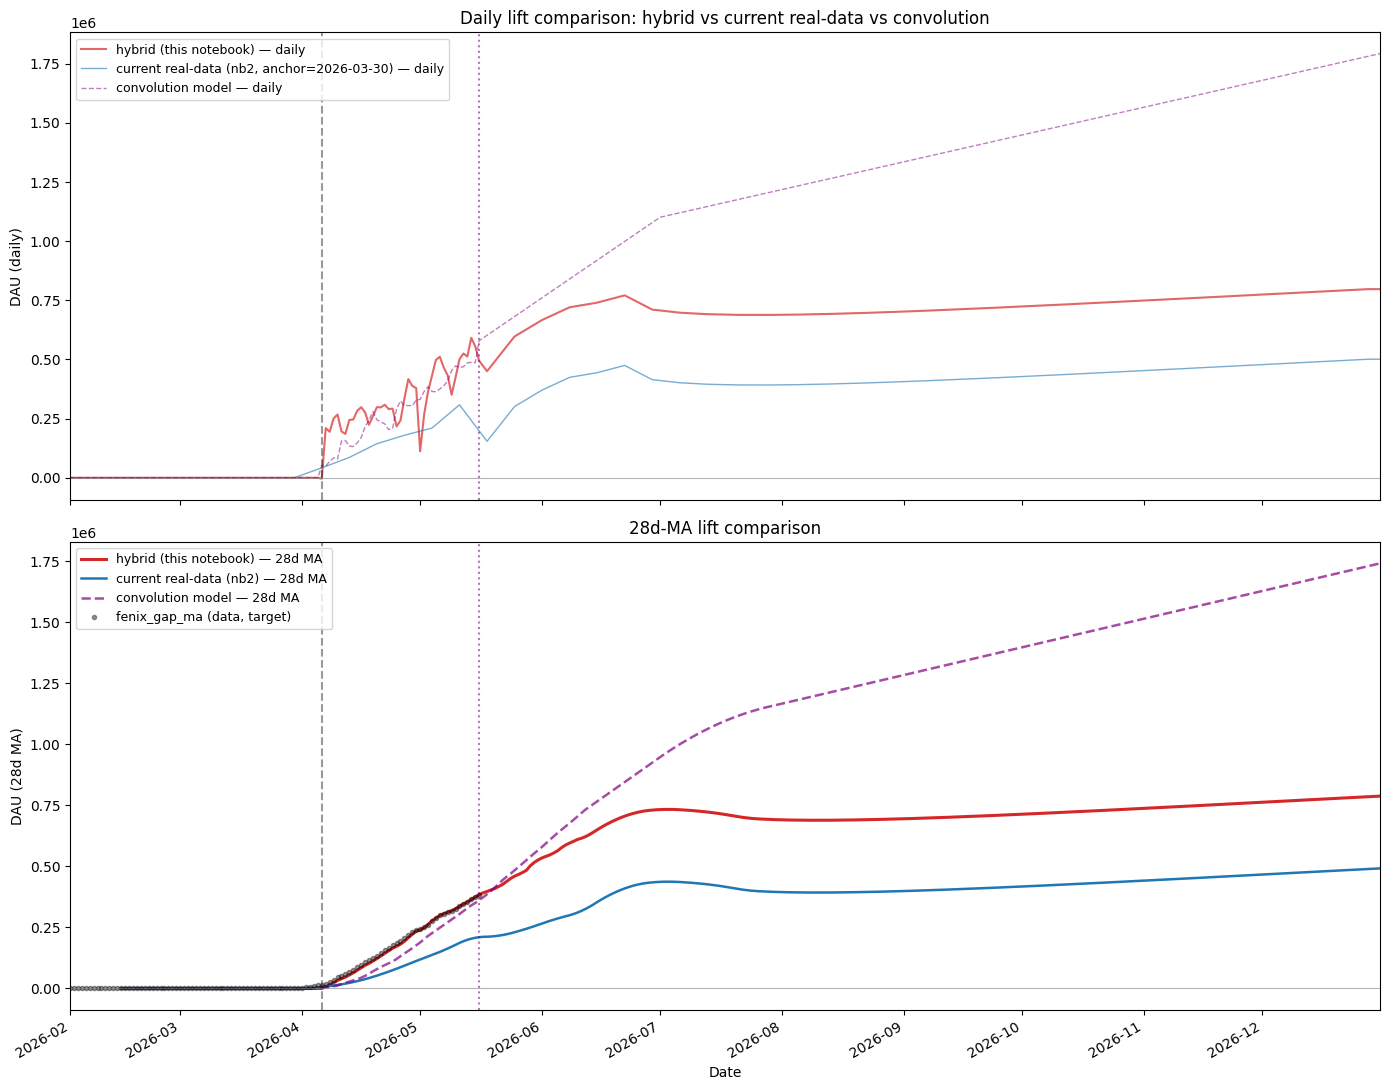

Year-end magnitudes:
  hybrid daily lift @ 2026-12-31:         +797,352
  hybrid 28d MA   @ 2026-12-31:           +788,275
  current real-data daily @ 12-31:       +501,073
  current real-data 28d MA @ 12-31:      +491,996
  convolution daily @ 12-31:           +1,793,319
  convolution 28d MA @ 12-31:          +1,742,270


In [7]:
# [comparison-plot]
# Overlay hybrid, current real-data model (anchor=2026-03-30), and convolution model.
# Daily and 28d MA panels.

fig, (ax_daily, ax_ma) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

# Hybrid
ax_daily.plot(hybrid_lift.index, hybrid_lift.values, '-', linewidth=1.5, color='C3', alpha=0.7,
              label='hybrid (this notebook) — daily')
ax_ma.plot(hybrid_lift_ma.index, hybrid_lift_ma.values, '-', linewidth=2.2, color='C3',
           label='hybrid (this notebook) — 28d MA')

# Current real-data model
try:
    rd_df = pd.read_parquet(CURRENT_REAL_DATA_PARQUET)
    ax_daily.plot(rd_df.index, rd_df['marketing_lift_daily'], '-', linewidth=1.0, color='C0', alpha=0.6,
                  label='current real-data (nb2, anchor=2026-03-30) — daily')
    ax_ma.plot(rd_df.index, rd_df['marketing_lift_ma'], '-', linewidth=1.8, color='C0',
               label='current real-data (nb2) — 28d MA')
except Exception as exc:
    print(f'WARN: could not load current real-data parquet: {exc}')

# Convolution model
try:
    conv_df = pd.read_parquet(EXISTING_CONVOLUTION_PARQUET)
    ax_daily.plot(conv_df.index, conv_df['marketing_lift_daily'], '--', linewidth=1.0, color='purple', alpha=0.5,
                  label='convolution model — daily')
    ax_ma.plot(conv_df.index, conv_df['marketing_lift_ma'], '--', linewidth=1.8, color='purple', alpha=0.7,
               label='convolution model — 28d MA')
except Exception as exc:
    print(f'WARN: could not load convolution model: {exc}')

# Empirical gap (Fenix) for reference
ax_ma.plot(fenix_gap_ma.index, fenix_gap_ma.values, 'o', markersize=3, color='black', alpha=0.4,
           label='fenix_gap_ma (data, target)')

for ax in (ax_daily, ax_ma):
    ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
    ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
    ax.axvline(training_end, color='purple', linestyle=':', alpha=0.55)
    ax.set_xlim(PLOT_START, PLOT_END)
    ax.legend(fontsize=9, loc='upper left')

ax_daily.set_title('Daily lift comparison: hybrid vs current real-data vs convolution')
ax_daily.set_ylabel('DAU (daily)')
ax_ma.set_title('28d-MA lift comparison')
ax_ma.set_ylabel('DAU (28d MA)')
ax_ma.set_xlabel('Date')
ax_ma.xaxis.set_major_locator(mdates.MonthLocator())
ax_ma.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Year-end magnitudes
print('Year-end magnitudes:')
print(f'  hybrid daily lift @ 2026-12-31:       {hybrid_lift.loc[PARQUET_END]:>+10,.0f}')
print(f'  hybrid 28d MA   @ 2026-12-31:         {hybrid_lift_ma.loc[PARQUET_END]:>+10,.0f}')
try:
    print(f'  current real-data daily @ 12-31:     {rd_df["marketing_lift_daily"].iloc[-1]:>+10,.0f}')
    print(f'  current real-data 28d MA @ 12-31:    {rd_df["marketing_lift_ma"].iloc[-1]:>+10,.0f}')
    print(f'  convolution daily @ 12-31:           {conv_df["marketing_lift_daily"].iloc[-1]:>+10,.0f}')
    print(f'  convolution 28d MA @ 12-31:          {conv_df["marketing_lift_ma"].iloc[-1]:>+10,.0f}')
except NameError:
    pass


In [8]:
# [build-and-write-artifact]
export_df = pd.DataFrame({
    'marketing_lift_daily': hybrid_lift.astype('float64'),
    'marketing_lift_ma': hybrid_lift_ma.astype('float64'),
})
export_df.index.name = 'target_date'
export_df.index = pd.DatetimeIndex(export_df.index).normalize()

reference_df = pd.read_parquet(EXISTING_CONVOLUTION_PARQUET)
assert list(export_df.columns) == list(reference_df.columns)
assert export_df.dtypes.to_dict() == reference_df.dtypes.to_dict()
assert export_df.index.name == reference_df.index.name == 'target_date'
assert export_df.index.dtype == reference_df.index.dtype
assert export_df.index.is_unique
assert export_df.index.is_monotonic_increasing
assert export_df.index.min() == PARQUET_START
assert export_df.index.max() == PARQUET_END

OUT_PARQUET.parent.mkdir(exist_ok=True)
export_df.to_parquet(OUT_PARQUET)

artifact_sha1 = hashlib.sha1(OUT_PARQUET.read_bytes()).hexdigest()
source_csv_sha1 = hashlib.sha1(SOURCE_CSV.read_bytes()).hexdigest()

print(f'Wrote {OUT_PARQUET}')
print(f'  size: {OUT_PARQUET.stat().st_size:,} bytes')
print(f'  sha1: {artifact_sha1}')

git_hash = subprocess.check_output(
    ['git', 'rev-parse', 'HEAD'],
    cwd='/Users/brendanwells/work/mozaic-daily',
).decode().strip()

meta = {
    "model_name": "fenix_marketing_lift_hybrid_v1",
    "description": (
        "Hybrid marketing-lift series. Historical period (2026-04-06 → 2026-05-19): "
        "lift = empirical Fenix Android gap (June actuals − April mktg-off forecast). "
        "Future period (2026-05-20 → 2026-12-31): lift anchored at empirical level on "
        "training_end, growing per the marketing-team CSV's pattern from there. "
        "No interpolation slope-calculation; no anchor choice required."
    ),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "mozaic_daily_git_hash": git_hash,
    "coverage": {
        "start_date": str(PARQUET_START.date()),
        "end_date": str(PARQUET_END.date()),
        "campaign_launch": str(CAMPAIGN_LAUNCH.date()),
        "training_end": str(training_end.date()),
        "forecast_end": str(PARQUET_END.date()),
    },
    "methodology": {
        "framing": "hybrid: empirical-actuals for historical period, CSV-anchored projection for future",
        "historical_rule": "lift(d) = fenix_gap_daily(d) for d in [CAMPAIGN_LAUNCH, training_end]; 0 pre-campaign",
        "future_rule": "lift(d) = gap_at_training_end + (csv_daily_paid(d) − csv_daily_paid(training_end)) for d > training_end",
        "gap_scope": "country='ALL', app_name='fenix_android' (Fenix-only since campaign is Fenix-only)",
        "no_smoothing": "raw daily gap used as historical lift; future portion uses linearly-interpolated CSV"
    },
    "source_data": {
        "source_csv": str(SOURCE_CSV),
        "source_csv_sha1": source_csv_sha1,
        "april_forecast": str(APRIL_FORECAST_PATH),
        "june_forecast": str(JUNE_FORECAST_PATH),
        "upstream_query_reference": "STMO 118452 (DS team — reference only)",
        "upstream_dashboard_url": "https://sql.telemetry.mozilla.org/queries/118452/source",
        "upstream_team_attribution": {
            "csv_source": "marketing team",
            "stmo_118452": "DS team",
            "geo_testing_tables": "WRONG — flagged by user 2026-05-19, do not use"
        }
    },
    "validation": {
        "a_n_compare_days": int(len(a_resid)),
        "a_residual_mean": a_resid_mean,
        "a_residual_std": a_resid_std,
        "a_residual_rmse": a_resid_rmse,
        "a_note": "expected small but not exactly zero; 28d MA at boundary mixes historical (gap) with future (CSV-anchored) values",
        "c_n_counterfactual_days": int(len(c_resid)),
        "c_residual_mean": c_resid_mean,
        "c_residual_std": c_resid_std,
        "c_residual_min": c_resid_min,
        "c_residual_max": c_resid_max,
    },
    "caveats": [
        "Historical lift = raw daily fenix_gap_daily. This carries the day-to-day noise of (actuals − april_forecast), including DOW effects and any non-marketing April-forecast errors. The applier consumes daily values; the noise propagates.",
        "Future lift = anchored CSV-derived projection. Carries the same channel-filter / ex-Iran assumptions noted in questions_for_marketing_analyst.md.",
        "Pre-campaign (< 2026-04-06) is set to 0 by convention. Any pre-campaign actuals-vs-april drift is treated as non-marketing.",
        "All three Paid-DAU definitions described in 01_signal_extraction.ipynb apply here too — the CSV is the source of truth for forward projection; STMO 118452 is reference only; geo_testing tables are wrong."
    ],
    "source_notebooks": [
        "01_signal_extraction.ipynb",
        "04_hybrid_lift.ipynb"
    ],
    "export_columns": {
        "marketing_lift_daily": (
            "Daily Fenix Android marketing-attributable lift. 0 pre-campaign. "
            "Historical: raw daily (actuals − april mktg-off forecast). "
            "Future: anchored CSV-derived projection."
        ),
        "marketing_lift_ma": (
            "28-day trailing moving average of marketing_lift_daily. NaN for first 13 days. "
            "Diagnostic only; not consumed by the m applier."
        )
    },
    "artifact_sha1": artifact_sha1
}

with open(OUT_META, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Wrote {OUT_META}')


Wrote data/marketing_lift_model.hybrid.2026-05-19.parquet
  size: 10,104 bytes
  sha1: a20bbb69f544475170c5c040b4433135116a02a5


Wrote data/marketing_lift_model.hybrid.2026-05-19.meta.json


In [9]:
# [validate-via-loader]
loaded = pd.read_parquet(OUT_PARQUET)
series = loaded['marketing_lift_daily'].copy()
series.index = pd.DatetimeIndex(series.index).normalize()

assert series.index.is_unique, 'index must be unique'
assert series.index.is_monotonic_increasing, 'index must be sorted'
assert not series.isna().any(), 'no NaN in daily values'
assert (series.loc[:CAMPAIGN_LAUNCH - pd.Timedelta(days=1)] == 0.0).all(), 'pre-launch lift must all be 0'

print('Loader-contract check: PASS')
print(f'  - index unique:      {series.index.is_unique}')
print(f'  - index sorted:      {series.index.is_monotonic_increasing}')
print(f'  - no NaN:            {not series.isna().any()}')
print(f'  - midnight index:    {(series.index == series.index.normalize()).all()}')
print(f'  - pre-launch zero:   {(series.loc[:CAMPAIGN_LAUNCH - pd.Timedelta(days=1)] == 0.0).all()}')
print(f'  - launch-day lift:   {series.loc[CAMPAIGN_LAUNCH]:>+10,.0f}')
print(f'  - training_end lift: {series.loc[training_end]:>+10,.0f}')
print(f'  - year-end lift:     {series.loc[PARQUET_END]:>+10,.0f}')
print()
print(f'Artifact: {OUT_PARQUET}')
print(f'Sidecar:  {OUT_META}')


Loader-contract check: PASS
  - index unique:      True
  - index sorted:      True
  - no NaN:            True
  - midnight index:    True
  - pre-launch zero:   True
  - launch-day lift:       -3,985
  - training_end lift:   +494,378
  - year-end lift:       +797,352

Artifact: data/marketing_lift_model.hybrid.2026-05-19.parquet
Sidecar:  data/marketing_lift_model.hybrid.2026-05-19.meta.json
